In [1]:
!pip install folium

Adding various required libraries

In [2]:

from ast import increment_lineno
import pandas as pd
from sklearn.cluster import KMeans
import folium
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Code for reading the csv file containing the data

In [3]:

df = pd.read_csv("Data.csv")
df.head()

,Sl. No.,Name of District,Name of Police Station,Name of Landmark,Name of Location,Lattitude,Longitude,Name of Road,HOSPITAL NEAR LATITUDE,HOSPITAL NEAR LONGITUDE,Accident Severity Index,Type of Road,Number of Fatalities,Sum of Fatal & Grievous Injury Crashes
0,1,Thiruvananthapuram,Karamana,Pappanamcode Mosque - Kerala Gramin Bank,Pappanamcode Junction,8.470460,76.980803,National Highway 66 (NH 66),8.724141,77.028555,366,NH,15,102
1,2,Kollam,Chavara PS,Regent Lake Palace - 110m before Hindustan Pet...,Parimanam Temple,8.954698,76.534274,National Highway 66 (NH 66),8.955805,76.534519,357,NH,17,99
2,3,Thiruvananthapuram,CITY TRAFFIC,Tax Towers - Karamana Junction,Karamana Junction,8.482015,76.967072,National Highway 66 (NH 66),8.481656,76.963152,314,NH,8,94
3,4,Malappuram,KUTTIPURAM,Vyapara Bhavan - 200m after Highway Junction,Kuttipuram Highway Junction,10.842810,76.030021,National Highway 66 (NH 66),10.854681,76.037121,306,NH,12,86
4,5,Thiruvananthapuram,Balaramapuram,Kodinada Junction - Indian Oil Petrol Pump,Balaramapuram Junction,8.430501,77.046417,National Highway 66 (NH 66),8.426988,77.043805,300,NH,6,92


K MEANS CLUSTERING

C:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


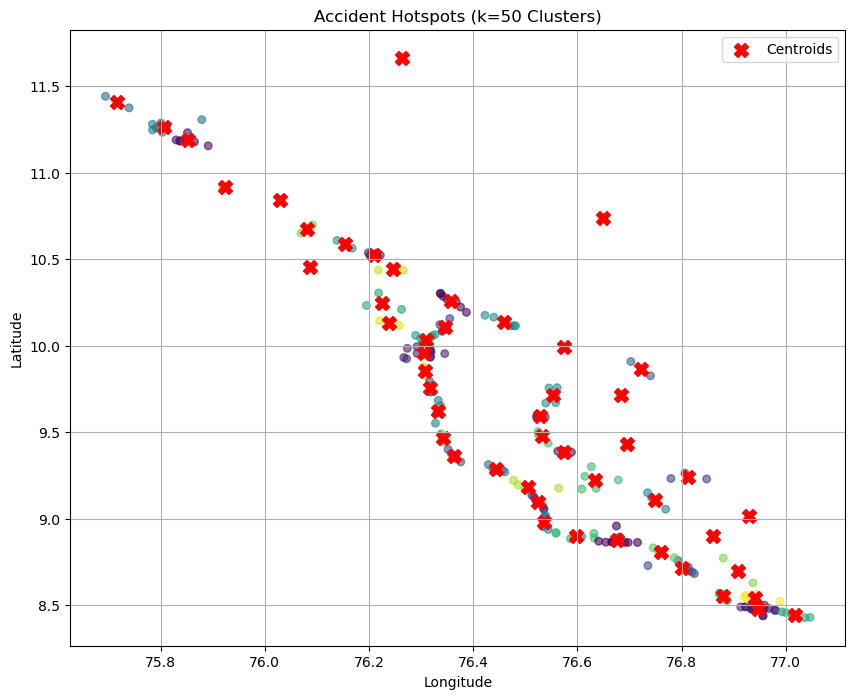

In [4]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Load the dataset
file_path = "Data.csv"
df = pd.read_csv(file_path)

# Extract latitude and longitude columns
latitude_col = 'Lattitude'
longitude_col = 'Longitude'
location_data = df[[latitude_col, longitude_col]]

# Set k to 50 for finer clustering
k = 50
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)

# Perform clustering and add the results to the DataFrame
df['Cluster'] = kmeans.fit_predict(location_data)

# Plot the clusters with distinct colors
plt.figure(figsize=(10, 8))
plt.scatter(df[longitude_col], df[latitude_col], c=df['Cluster'], cmap='viridis', s=30, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 0], s=100, c='red', marker='X', label='Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Accident Hotspots (k={k} Clusters)')
plt.legend()
plt.grid(True)
plt.show()


HOTSPOTS AND NEARBY HOSPITALS

C:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


    Hotspot_Latitude  Hotspot_Longitude  Nearest_Hospital_Latitude  \
0           8.879061          76.676438                   8.866118   
1          10.260898          76.356586                  10.261823   
2          11.186534          75.851985                  11.177240   
3           9.385539          76.575131                   9.387041   
4           8.479489          76.947180                   8.487510   
5           9.960216          76.305013                   9.953338   
6          10.526105          76.210031                  10.530190   
7           9.095106          76.524909                   9.109664   
8           9.591145          76.528047                   9.590657   
9          10.109595          76.346177                  10.107228   
10          9.242279          76.811301                   9.266749   
11         11.664126          76.262449                  11.665839   
12          8.714130          76.799807                   8.700241   
13          9.363624

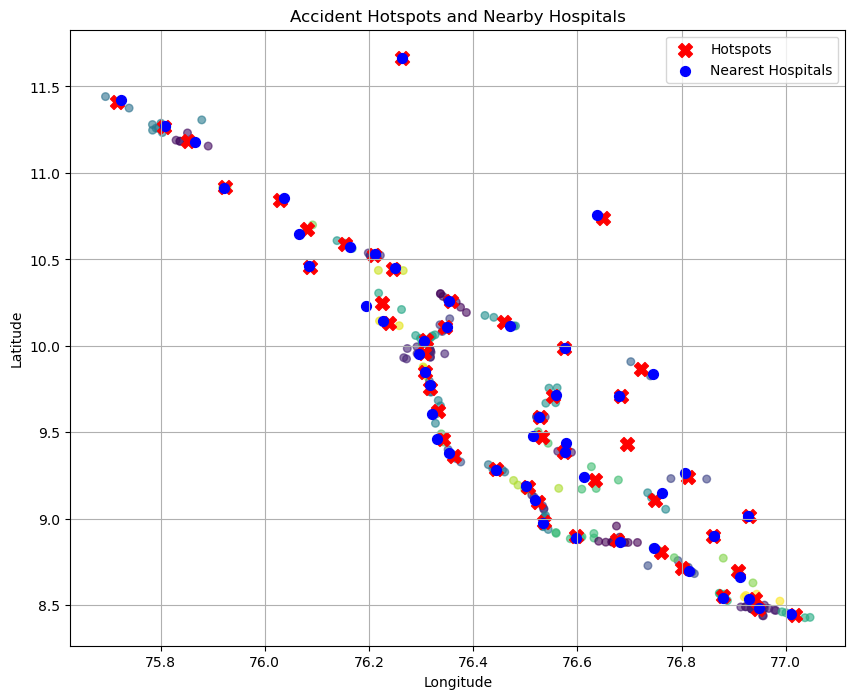

In [53]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances_argmin_min

# Load the dataset
file_path = "Data.csv"
df = pd.read_csv(file_path)

# Extract latitude and longitude columns for accidents
latitude_col = 'Lattitude'
longitude_col = 'Longitude'
location_data = df[[latitude_col, longitude_col]]

# Set k to 50 for clustering
k = 50
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)

# Perform clustering
df['Cluster'] = kmeans.fit_predict(location_data)

# Calculate cluster centers
centers = kmeans.cluster_centers_

# Assuming your hospitals data is also in the same DataFrame
# Replace 'Hospital_Latitude' and 'Hospital_Longitude' with the actual names in your dataset
hospital_latitude_col = 'HOSPITAL NEAR LATITUDE'
hospital_longitude_col = 'HOSPITAL NEAR LONGITUDE'

# Extract hospital locations
hospitals = df[[hospital_latitude_col, hospital_longitude_col]].dropna()

# Find the nearest hospitals to each cluster center
closest_hospitals_indices, distances = pairwise_distances_argmin_min(centers, hospitals)

# Create a DataFrame for hotspots with their nearest hospitals
hotspot_info = pd.DataFrame({
    'Hotspot_Latitude': centers[:, 0],
    'Hotspot_Longitude': centers[:, 1],
    'Nearest_Hospital_Latitude': hospitals.iloc[closest_hospitals_indices][hospital_latitude_col].values,
    'Nearest_Hospital_Longitude': hospitals.iloc[closest_hospitals_indices][hospital_longitude_col].values,
    'Distance_to_Hospital': distances
})

# Display hotspot information
print(hotspot_info)

# Plot the clusters with hospitals
plt.figure(figsize=(10, 8))
plt.scatter(df[longitude_col], df[latitude_col], c=df['Cluster'], cmap='viridis', s=30, alpha=0.6)
plt.scatter(centers[:, 1], centers[:, 0], s=100, c='red', marker='X', label='Hotspots')
plt.scatter(hotspot_info['Nearest_Hospital_Longitude'], hotspot_info['Nearest_Hospital_Latitude'], 
            s=50, c='blue', marker='o', label='Nearest Hospitals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Accident Hotspots and Nearby Hospitals')
plt.legend()
plt.grid(True)
plt.show()


In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Load the data
data = pd.read_csv("Data.csv")  # Replace with your dataset

# Strip any whitespace from column names
data.columns = data.columns.str.strip()

# Categorize the 'Accident Severity Index' into low, medium, and high
bins = [100, 140, float('inf')]  # Adjust these values based on your data distribution
labels = [0, 1]  # 0: low, 1: high
data['Severity Category'] = pd.cut(data['Accident Severity Index'], bins=bins, labels=labels, right=False)

# Prepare features and target variable
X = data[['Type of Road']]  # Features
y = data['Severity Category']  # Target variable

# One-hot encode categorical features
X = pd.get_dummies(X, drop_first=True)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[ 6 21]
 [ 1 20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.22      0.35        27
           1       0.49      0.95      0.65        21

    accuracy                           0.54        48
   macro avg       0.67      0.59      0.50        48
weighted avg       0.70      0.54      0.48        48



In [48]:
# Check for missing values in the target variable and relevant columns
print(data[['Sum of Fatal & Grievous Injury Crashes', 'Severity Category']].isnull().sum())


Sum of Fatal & Grievous Injury Crashes      0
Severity Category                         237
dtype: int64


In [16]:
wcss = []
for i in range(1,11):
    model = KMeans(n_clusters=i, n_init=10, random_state=0)
    y_kmeans = model.fit_predict(z)
    wcss.append(model.inertia_)

C:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

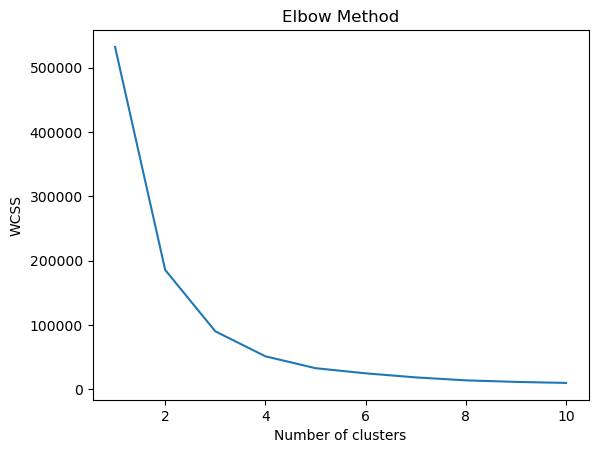

In [17]:

#Plotting it into the Elbow graph
plt.plot(range(1, 11), wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [8]:
import pandas as pd

# Load the data
data = pd.read_csv("Data.csv")  # Replace with your dataset

# Strip any whitespace from column names
data.columns = data.columns.str.strip()

# Group by 'Type of Road' and calculate the average severity index
severity_by_road_type = data.groupby('Type of Road')['Accident Severity Index'].mean().reset_index()

# Sort the results to find the road type with the highest severity
severity_by_road_type = severity_by_road_type.sort_values(by='Accident Severity Index', ascending=False)

# Display the results
print(severity_by_road_type)


  Type of Road  Accident Severity Index
0           NH               157.720497
1           OR               142.444444
2           SH               134.340000


In [18]:
#Clustering the data into 3 clusters
model = KMeans(n_clusters=50)
y_kmeans = model.fit_predict(z)
df['y'] = y_kmeans

C:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


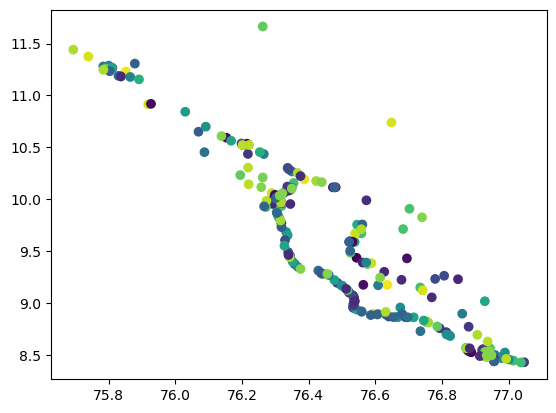

In [19]:
#Creating clusters
plt.scatter(df['Longitude'], df['Lattitude'],c=df['y'],)

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
df['y'] = pd.Categorical(df.y)
df.y.value_counts()

43    14
14    12
16    12
38    10
34    10
8     10
7      9
2      8
44     8
0      7
26     7
23     7
19     7
39     7
47     7
48     7
13     6
3      6
20     6
27     5
9      5
5      5
30     5
37     4
33     4
15     4
45     4
24     4
21     4
28     3
10     3
42     3
1      2
41     2
18     2
17     2
36     2
12     2
11     2
46     1
25     1
40     1
35     1
32     1
31     1
29     1
22     1
6      1
4      1
49     1
Name: y, dtype: int64

<Axes: xlabel='y', ylabel='count'>

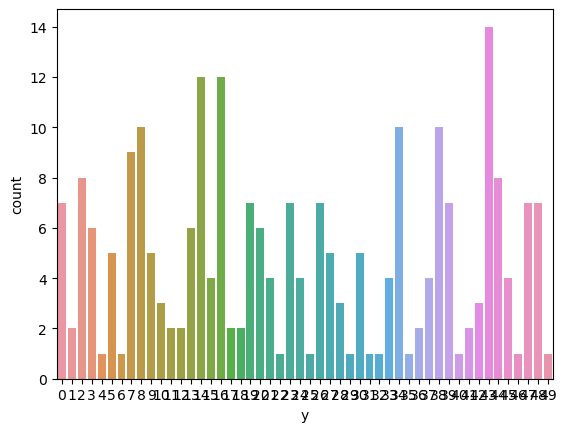

In [10]:
sns.countplot(x ='y', data = df)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [35]:
# Creating a binary target: 1 if severity index > threshold, else 0
threshold = 200
df['High_Risk'] = df['Accident Severity Index'].apply(lambda x: 1 if x > threshold else 0)

In [36]:
# Features and target
X = df[['Number of Fatalities', 'Sum of Fatal & Grievous Injury Crashes']]
y = df['High_Risk']


In [37]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [38]:
# Logistic Regression model
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [13]:
# Predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        41
           1       1.00      1.00      1.00         7

    accuracy                           1.00        48
   macro avg       1.00      1.00      1.00        48
weighted avg       1.00      1.00      1.00        48



In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df[['Lattitude', 'Longitude', 'Number of Fatalities', 'Sum of Fatal & Grievous Injury Crashes']]
y = df['Accident Severity Index']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Predictions and evaluation
y_pred = lin_reg.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-squared:", r2_score(y_test, y_pred))

Mean Squared Error: 8.438015207430746
R-squared: 0.9959555690976247


ANOMALIES

C:\Users\chris\anaconda3\Lib\site-packages\sklearn\base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


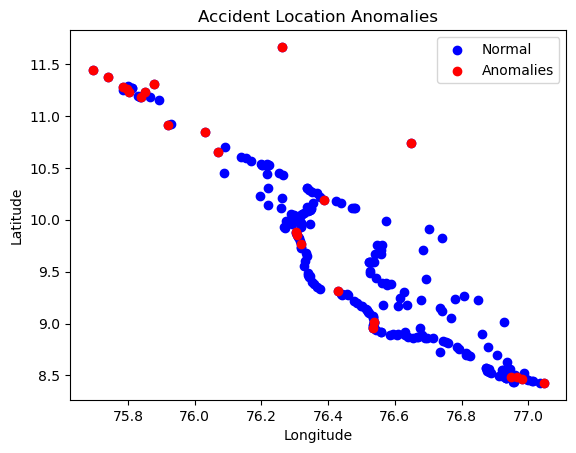

In [19]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Selecting the relevant features
location_data = df[['Lattitude', 'Longitude', 'Accident Severity Index', 'Number of Fatalities']]

# Isolation Forest for anomaly detection
iso_forest = IsolationForest(contamination=0.1, random_state=0)
df['Anomaly'] = iso_forest.fit_predict(location_data)

# Filtering out anomalies (outliers)
anomalies = df[df['Anomaly'] == -1]

# Visualizing anomalies on the map
plt.scatter(df['Longitude'], df['Lattitude'], label='Normal', color='blue')
plt.scatter(anomalies['Longitude'], anomalies['Lattitude'], label='Anomalies', color='red')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.title('Accident Location Anomalies')
plt.show()


C:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Users\chris\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


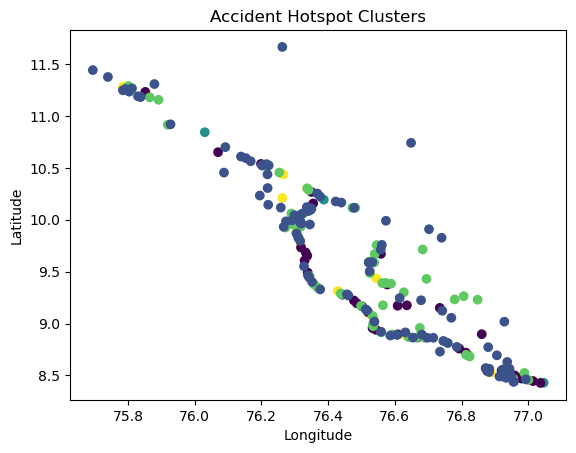

In [56]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Selecting relevant features
location_data = df[['Lattitude', 'Longitude', 'Accident Severity Index', 'Number of Fatalities']]

# Initializing and fitting KMeans with an arbitrary choice of clusters (e.g., 5)
kmeans = KMeans(n_clusters=5, random_state=0)
df['Cluster'] = kmeans.fit_predict(location_data)

# Visualizing clusters
plt.scatter(df['Longitude'], df['Lattitude'], c=df['Cluster'], cmap='viridis')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Accident Hotspot Clusters')
plt.show()


In [20]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Set k to 50 for a finer clustering
k = 50
kmeans = KMeans(n_clusters=k, n_init=10, random_state=0)
df['Cluster'] = kmeans.fit_predict(location_data)

# Plot the clusters with distinct colors
plt.figure(figsize=(10, 8))
plt.scatter(df['Longitude'], df['Lattitude'], c=df['Cluster'], cmap='viridis', s=30, alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 0], s=100, c='red', marker='X', label='Centroids')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Accident Hotspots (k={k} Clusters)')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'location_data' is not defined